# 🐦 Fine-Grained Bird Species Classification using CUB-200-2011

## Project Overview
This notebook performs:
- Dataset loading from Kaggle
- Exploratory Data Analysis (EDA)
- Dataset visualizations
- CNN-based model training
- Training & validation metric visualization

**Dataset:** CUB-200-2011 (200 bird species)

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from sklearn.metrics import confusion_matrix, classification_report

sns.set_style('whitegrid')

## 📂 Dataset Path Configuration

In [2]:
import kagglehub
dataset = kagglehub.dataset_download("wenewone/cub2002011")

dataset

100%|██████████| 1.49G/1.49G [00:19<00:00, 81.2MB/s]

Extracting files...


'/root/.cache/kagglehub/datasets/wenewone/cub2002011/versions/7'

In [3]:
ls /root/.cache/kagglehub/datasets/wenewone/cub2002011/versions/7/CUB_200_2011/

attributes/         image_class_labels.txt  parts/
bounding_boxes.txt  images/                 README
classes.txt         images.txt              train_test_split.txt


In [4]:
from google.colab import files

files.download("/root/.cache/kagglehub/datasets/wenewone/cub2002011/versions/7/CUB_200_2011/classes.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:
CUB_ROOT = "/root/.cache/kagglehub/datasets/wenewone/cub2002011/versions/7/CUB_200_2011"
IMG_DIR = os.path.join(CUB_ROOT, "images")

## 🔍 Dataset Visual Inspection

In [6]:
images_df = pd.read_csv(
    os.path.join(CUB_ROOT, "images.txt"),
    sep=" ",
    names=["img_id", "filepath"]
)

labels_df = pd.read_csv(
    os.path.join(CUB_ROOT, "image_class_labels.txt"),
    sep=" ",
    names=["img_id", "class_id"]
)

split_df = pd.read_csv(
    os.path.join(CUB_ROOT, "train_test_split.txt"),
    sep=" ",
    names=["img_id", "is_train"]
)

classes_df = pd.read_csv(
    os.path.join(CUB_ROOT, "classes.txt"),
    sep=" ",
    names=["class_id", "class_name"]
)


In [7]:
data_df = images_df.merge(labels_df, on="img_id")
data_df = data_df.merge(split_df, on="img_id")
data_df = data_df.merge(classes_df, on="class_id")

print("Total images:", len(data_df))
print(data_df.head())

Total images: 11788
   img_id                                           filepath  class_id  \
0       1  001.Black_footed_Albatross/Black_Footed_Albatr...         1   
1       2  001.Black_footed_Albatross/Black_Footed_Albatr...         1   
2       3  001.Black_footed_Albatross/Black_Footed_Albatr...         1   
3       4  001.Black_footed_Albatross/Black_Footed_Albatr...         1   
4       5  001.Black_footed_Albatross/Black_Footed_Albatr...         1   

   is_train                  class_name  
0         0  001.Black_footed_Albatross  
1         1  001.Black_footed_Albatross  
2         0  001.Black_footed_Albatross  
3         1  001.Black_footed_Albatross  
4         1  001.Black_footed_Albatross  


Train / Test Split

In [8]:
train_df = data_df[data_df.is_train == 1]
test_df  = data_df[data_df.is_train == 0]

print("Training samples:", len(train_df))
print("Testing samples:", len(test_df))


Training samples: 5994
Testing samples: 5794


In [28]:
import os
from PIL import Image
from torch.utils.data import Dataset

class CUBDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row.filepath)
        image = Image.open(img_path).convert("RGB")
        label = int(row.class_id) - 1  # 1–200 → 0–199

        if self.transform:
            image = self.transform(image)

        return image, label

## 📊 Class Distribution Analysis

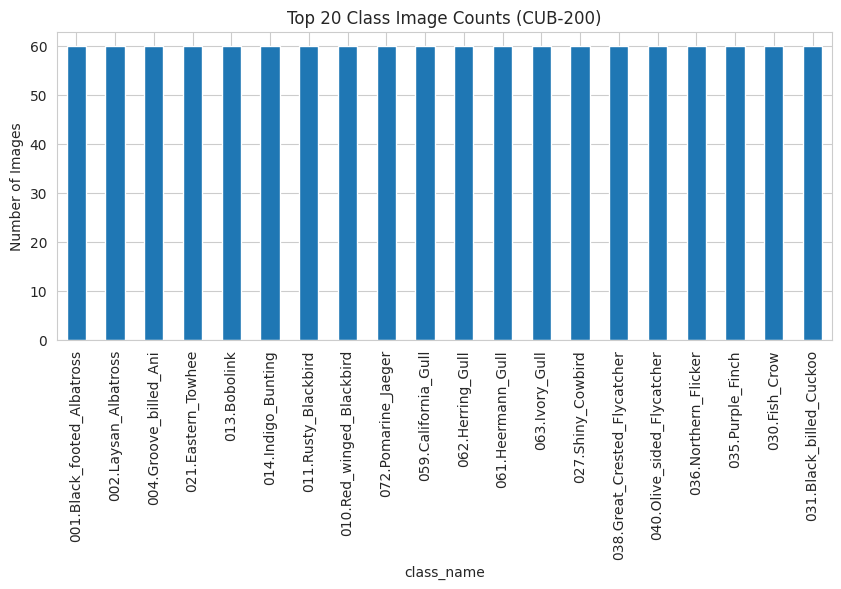

In [9]:
plt.figure(figsize=(10,4))
data_df["class_name"].value_counts().head(20).plot(kind="bar")
plt.title("Top 20 Class Image Counts (CUB-200)")
plt.ylabel("Number of Images")
plt.show()


Sample Image Visualization

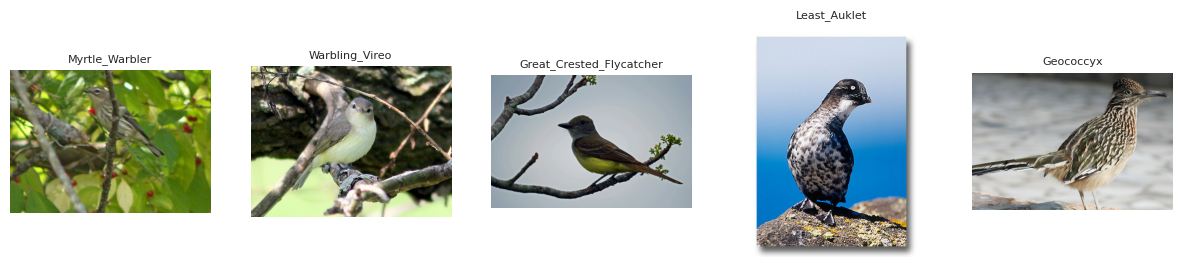

In [10]:
sample_rows = train_df.sample(5)

plt.figure(figsize=(15,3))
for i, row in enumerate(sample_rows.itertuples()):
    img = Image.open(os.path.join(IMG_DIR, row.filepath))
    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.title(row.class_name.split(".")[-1], fontsize=8)
    plt.axis("off")

plt.show()

Image Resolution Analysis

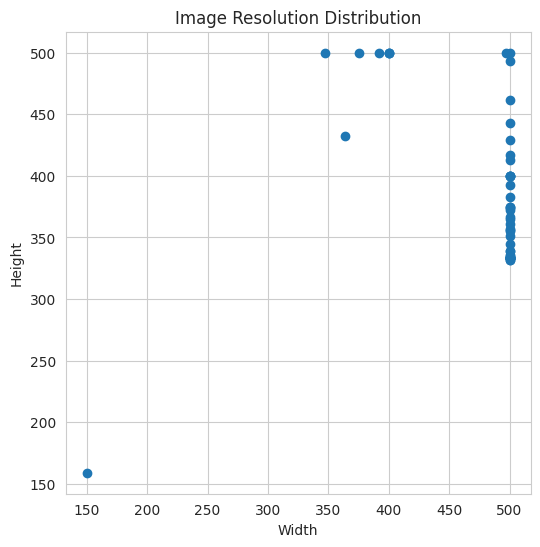

In [11]:
widths, heights = [], []

for row in train_df.sample(50).itertuples():
    img = Image.open(os.path.join(IMG_DIR, row.filepath))
    widths.append(img.size[0])
    heights.append(img.size[1])

plt.figure(figsize=(6,6))
plt.scatter(widths, heights)
plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Image Resolution Distribution")
plt.show()

In [29]:
# =========================
# GLOBAL CONFIG
# =========================
NUM_CLASSES = 200
IMG_SIZE = 456          # EfficientNet-B5
BATCH_SIZE = 16
TOTAL_EPOCHS = 30

PHASE1_EPOCHS = 8       # classifier only
PHASE2_EPOCHS = 10      # partial fine-tune
PHASE3_EPOCHS = 12      # full fine-tune

BEST_MODEL_PATH = "best_cub200_efficientnet_b5.pth"


In [30]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [31]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.3, 0.3, 0.3, 0.1),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [32]:
from torch.utils.data import DataLoader

train_dataset = CUBDataset(train_df, IMG_DIR, train_transform)
val_dataset   = CUBDataset(test_df, IMG_DIR, val_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Data loaders ready")


Data loaders ready


In [33]:
import torch.nn as nn
from torchvision.models import efficientnet_b5, EfficientNet_B5_Weights

model = efficientnet_b5(
    weights=EfficientNet_B5_Weights.IMAGENET1K_V1
)

# Freeze everything
for param in model.parameters():
    param.requires_grad = False

# Replace classifier
model.classifier[1] = nn.Linear(
    model.classifier[1].in_features, NUM_CLASSES
)

model = model.to(device)

print("Model ready")


Downloading: "https://download.pytorch.org/models/efficientnet_b5_lukemelas-1a07897c.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b5_lukemelas-1a07897c.pth


100%|██████████| 117M/117M [00:00<00:00, 166MB/s]


Model ready


In [34]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW(
    model.classifier.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=TOTAL_EPOCHS
)


In [35]:
def train_one_epoch(model, loader, optimizer):
    model.train()
    correct, total = 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, preds = outputs.max(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return correct / total


def validate(model, loader):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = outputs.max(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total


In [36]:
best_val_acc = 0.0
epoch_counter = 0

print("========== PHASE 1: CLASSIFIER ONLY ==========")
for _ in range(PHASE1_EPOCHS):
    epoch_counter += 1
    train_acc = train_one_epoch(model, train_loader, optimizer)
    val_acc = validate(model, val_loader)
    scheduler.step()

    print(f"Epoch {epoch_counter}/{TOTAL_EPOCHS} | Train: {train_acc:.4f} | Val: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), BEST_MODEL_PATH)


print("========== PHASE 2: UNFREEZE LAST 2 BLOCKS ==========")
for param in model.features[-2:].parameters():
    param.requires_grad = True

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

for _ in range(PHASE2_EPOCHS):
    epoch_counter += 1
    train_acc = train_one_epoch(model, train_loader, optimizer)
    val_acc = validate(model, val_loader)
    scheduler.step()

    print(f"Epoch {epoch_counter}/{TOTAL_EPOCHS} | Train: {train_acc:.4f} | Val: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), BEST_MODEL_PATH)


print("========== PHASE 3: FULL FINE-TUNING ==========")
for param in model.parameters():
    param.requires_grad = True

optimizer = optim.AdamW(
    model.parameters(),
    lr=5e-5,
    weight_decay=1e-4
)

for _ in range(PHASE3_EPOCHS):
    epoch_counter += 1
    train_acc = train_one_epoch(model, train_loader, optimizer)
    val_acc = validate(model, val_loader)
    scheduler.step()

    print(f"Epoch {epoch_counter}/{TOTAL_EPOCHS} | Train: {train_acc:.4f} | Val: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), BEST_MODEL_PATH)

print("==============================================")
print("TRAINING COMPLETE")
print("BEST VALIDATION ACCURACY:", best_val_acc)
print("MODEL SAVED AT:", BEST_MODEL_PATH)


========== PHASE 1: CLASSIFIER ONLY ==========
Epoch 1/30 | Train: 0.1363 | Val: 0.4296
Epoch 2/30 | Train: 0.4162 | Val: 0.5138
Epoch 3/30 | Train: 0.5417 | Val: 0.5551
Epoch 4/30 | Train: 0.5903 | Val: 0.5842
Epoch 5/30 | Train: 0.6103 | Val: 0.6048
Epoch 6/30 | Train: 0.6480 | Val: 0.6274
Epoch 7/30 | Train: 0.6717 | Val: 0.6389
Epoch 8/30 | Train: 0.6845 | Val: 0.6510
========== PHASE 2: UNFREEZE LAST 2 BLOCKS ==========
Epoch 9/30 | Train: 0.7377 | Val: 0.7366
Epoch 10/30 | Train: 0.8068 | Val: 0.7729
Epoch 11/30 | Train: 0.8527 | Val: 0.7884
Epoch 12/30 | Train: 0.8794 | Val: 0.7943
Epoch 13/30 | Train: 0.9061 | Val: 0.8065
Epoch 14/30 | Train: 0.9273 | Val: 0.8067
Epoch 15/30 | Train: 0.9443 | Val: 0.8076
Epoch 16/30 | Train: 0.9453 | Val: 0.8051
Epoch 17/30 | Train: 0.9615 | Val: 0.8074
Epoch 18/30 | Train: 0.9716 | Val: 0.8171
========== PHASE 3: FULL FINE-TUNING ==========


OutOfMemoryError: CUDA out of memory. Tried to allocate 40.00 MiB. GPU 0 has a total capacity of 14.74 GiB of which 22.12 MiB is free. Process 3171 has 14.72 GiB memory in use. Of the allocated memory 14.41 GiB is allocated by PyTorch, and 177.22 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [37]:
print(BEST_MODEL_PATH)

best_cub200_efficientnet_b5.pth


In [38]:
from google.colab import files
files.download(BEST_MODEL_PATH)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

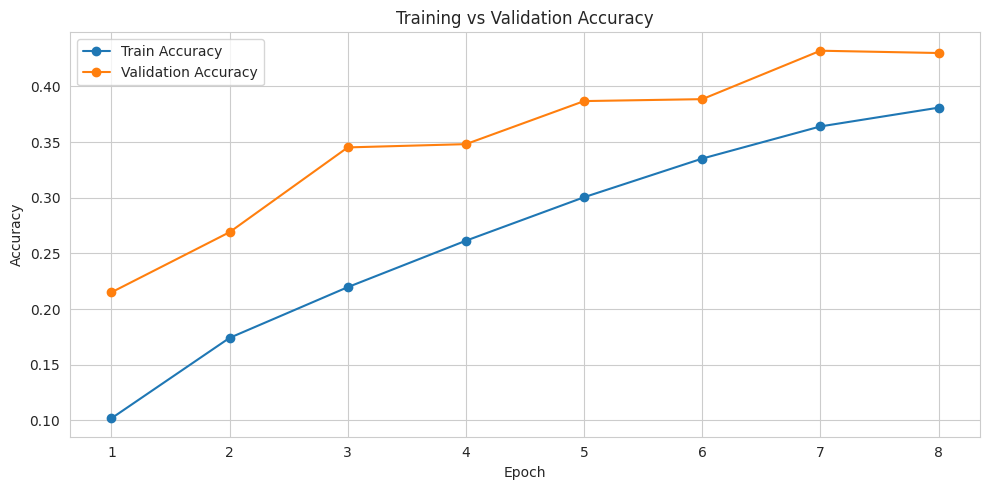

In [39]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_accs) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, train_accs, label="Train Accuracy", marker='o')
plt.plot(epochs, val_accs, label="Validation Accuracy", marker='o')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


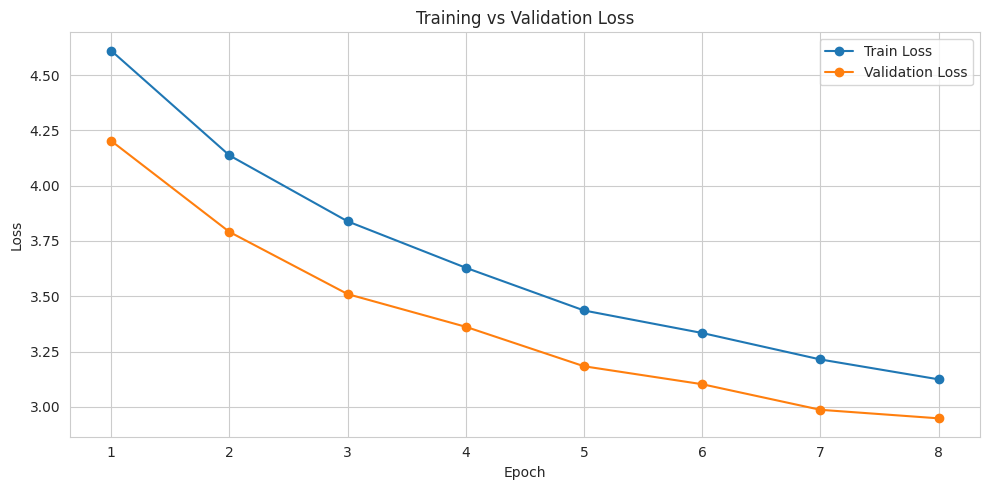

In [40]:
if 'train_losses' in globals() and 'val_losses' in globals():
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(10, 5))
    plt.plot(epochs, train_losses, label="Train Loss", marker='o')
    plt.plot(epochs, val_losses, label="Validation Loss", marker='o')

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


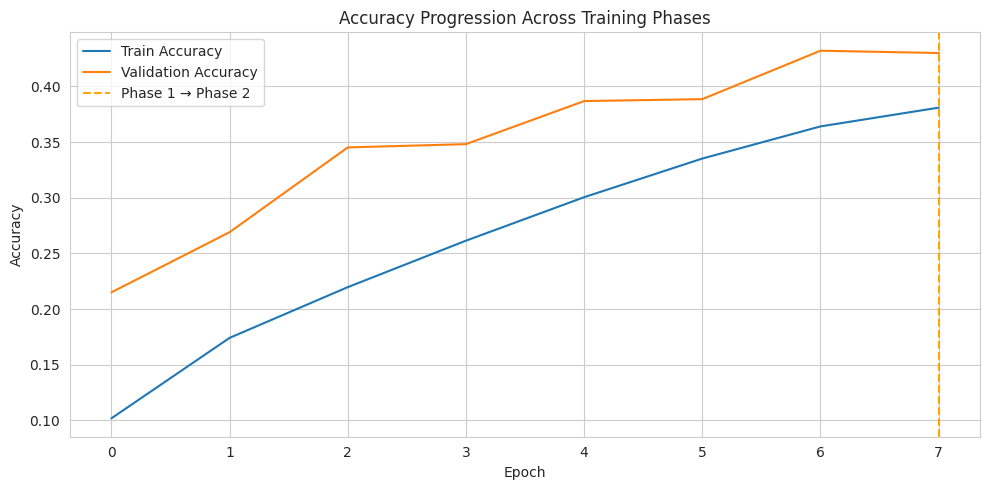

In [42]:
plt.figure(figsize=(10, 5))
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")

# Phase boundaries
plt.axvline(x=PHASE1_EPOCHS - 1, color='orange', linestyle='--', label='Phase 1 → Phase 2')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Progression Across Training Phases")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
